<a href="https://colab.research.google.com/github/AnnaNaumchuk/Retail-Store-Analytics-Dashboard/blob/main/%D0%97%D0%B0%D0%B3%D0%B0%D0%BB%D1%8C%D0%BD%D0%B8%D0%B9_%D0%B0%D0%BD%D0%B0%D0%BB%D1%96%D0%B7_%D0%B7%D0%BD%D0%B8%D0%B6%D0%BE%D0%BA_%D0%B4%D0%BB%D1%8F_%D0%BC%D0%B0%D0%B3%D0%B0%D0%B7%D0%B8%D0%BD%D1%83_%D0%BE%D0%B4%D1%8F%D0%B3%D1%83.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Підготовка таблиці та основні розрахунки**

In [1]:
import pandas as pd
import numpy as np

# -------------------------------------------------------------------------
# КРОК 1: Завантаження даних та фіксація часових індексів
# -------------------------------------------------------------------------

# Завантажуємо датасет
df = pd.read_csv("Таблиця для аналізу продажів.csv")

# Переводимо дату у правильний часовий формат для Python
df['Дата'] = pd.to_datetime(df['Дата'])

# Створюємо безперервний місячний період (наприклад, '2025-03') для аналізу трендів
df['Часовий_Місяць'] = df['Дата'].dt.to_period('M')


# -------------------------------------------------------------------------
# КРОК 2: Розрахунок базових фінансових метрик мережі
# -------------------------------------------------------------------------

print("="*60)
print(" ЕТАП 1: РОЗРАХУНОК ЗАГАЛЬНИХ МЕТРИК МЕРЕЖІ")
print("="*60)

# Загальна виручка (каса) - сума всіх грошей від клієнтів
total_revenue = df['Нетто Виторг (Каса)'].sum()

# Загальний чистий прибуток (маржа) за вирахуванням собівартості закупу
total_profit = df['Чистий прибуток (Маржа)'].sum()

# Реальна маржинальність мережі (у відсотках)
network_margin_pct = (total_profit / total_revenue) * 100

# Середній чек (виручка поділена на кількість унікальних чеків/замовлень)
total_orders = df['ID Замовлення'].nunique()
avg_ticket_global = total_revenue / total_orders

print(f"Загальна Виручка мережі (Каса): {total_revenue:,.2f} ₴")
print(f"Загальний Чистий Прибуток (Маржа): {total_profit:,.2f} ₴")
print(f"Глобальна Маржинальність мережі: {network_margin_pct:.2f}%")
print(f"Кількість унікальних замовлень: {total_orders} од.")
print(f"Глобальний Середній Чек: {avg_ticket_global:.2f} ₴\n")


# -------------------------------------------------------------------------
# КРОК 3: Аналіз динаміки Виручки, Прибутку, Маржі та Середнього Чека по місяцях
# -------------------------------------------------------------------------

print("="*60)
print(" ЕТАП 2: ДИНАМІКА МЕТРИК ПО МІСЯЦЯХ (ПЕРЕВІРКА ЗАУВАЖЕНЬ)")
print("="*60)

# Г групуємо транзакції за місяцями
monthly_metrics = df.groupby('Часовий_Місяць').agg(
    Виручка_Каса=('Нетто Виторг (Каса)', 'sum'),
    Чистий_Прибуток_Маржа=('Чистий прибуток (Маржа)', 'sum'),
    Унікальних_Замовлень=('ID Замовлення', 'nunique'),
    Продано_Штук=('Кількість (шт)', 'sum')
).reset_index()

# Розраховуємо щомісячний середній чек
monthly_metrics['Середній_Чек'] = monthly_metrics['Виручка_Каса'] / monthly_metrics['Унікальних_Замовлень']

# Розраховуємо щомісячний відсоток маржинальності
monthly_metrics['Маржинальність_Pct'] = (monthly_metrics['Чистий_Прибуток_Маржа'] / monthly_metrics['Виручка_Каса']) * 100

# Виводимо результат у зрозумілому вигляді
for index, row in monthly_metrics.iterrows():
    print(f"Місяць: {row['Часовий_Місяць']}")
    print(f"  -> Виручка (Каса): {row['Виручка_Каса']:,.2f} ₴")
    print(f"  -> Чистий Прибуток: {row['Чистий_Прибуток_Маржа']:,.2f} ₴")
    print(f"  -> Середній Чек: {row['Середній_Чек']:.2f} ₴")
    print(f"  -> Маржинальність бізнесу: {row['Маржинальність_Pct']:.2f}%")
    print("-" * 40)


# -------------------------------------------------------------------------
# КРОК 4: Аналіз середнього чека та маржі в розрізі міст
# -------------------------------------------------------------------------

print("\n" + "="*60)
print(" ЕТАП 3: АНАЛІЗ ЕФЕКТИВНОСТІ ЛОКАЦІЙ (МІСТА)")
print("="*60)

city_metrics = df.groupby('Місто').agg(
    Виручка_Каса=('Нетто Виторг (Каса)', 'sum'),
    Чистий_Прибуток_Маржа=('Чистий прибуток (Маржа)', 'sum'),
    Унікальних_Замовлень=('ID Замовлення', 'nunique')
).reset_index()

city_metrics['Середній_Чек'] = city_metrics['Виручка_Каса'] / city_metrics['Унікальних_Замовлень']
city_metrics['Маржинальність_Pct'] = (city_metrics['Чистий_Прибуток_Маржа'] / city_metrics['Виручка_Каса']) * 100

print(city_metrics.to_string(index=False, formatters={
    'Виручка_Каса': '{:,.2f} ₴'.format,
    'Чистий_Прибуток_Маржа': '{:,.2f} ₴'.format,
    'Середній_Чек': '{:.2f} ₴'.format,
    'Маржинальність_Pct': '{:.2f}%'.format
}))

 ЕТАП 1: РОЗРАХУНОК ЗАГАЛЬНИХ МЕТРИК МЕРЕЖІ
Загальна Виручка мережі (Каса): 892,821.00 ₴
Загальний Чистий Прибуток (Маржа): 480,051.00 ₴
Глобальна Маржинальність мережі: 53.77%
Кількість унікальних замовлень: 561 од.
Глобальний Середній Чек: 1591.48 ₴

 ЕТАП 2: ДИНАМІКА МЕТРИК ПО МІСЯЦЯХ (ПЕРЕВІРКА ЗАУВАЖЕНЬ)
Місяць: 2025-03
  -> Виручка (Каса): 59,792.00 ₴
  -> Чистий Прибуток: 33,242.00 ₴
  -> Середній Чек: 1458.34 ₴
  -> Маржинальність бізнесу: 55.60%
----------------------------------------
Місяць: 2025-04
  -> Виручка (Каса): 60,310.00 ₴
  -> Чистий Прибуток: 32,600.00 ₴
  -> Середній Чек: 1470.98 ₴
  -> Маржинальність бізнесу: 54.05%
----------------------------------------
Місяць: 2025-05
  -> Виручка (Каса): 55,027.00 ₴
  -> Чистий Прибуток: 29,787.00 ₴
  -> Середній Чек: 1487.22 ₴
  -> Маржинальність бізнесу: 54.13%
----------------------------------------
Місяць: 2025-06
  -> Виручка (Каса): 47,025.00 ₴
  -> Чистий Прибуток: 25,825.00 ₴
  -> Середній Чек: 1679.46 ₴
  -> Маржи

**Глибокий аналіз сезонності та аналіз кількості проданих одиниць (Volume Analysis)**

 ЕТАП 2: АНАЛІЗ СПІВВІДНОШЕННЯ ВИРУЧКИ, ОБ'ЄМІВ ТА ЦІН
Часовий_Місяць Виручка_Каса Продано_Штук Середня_Ціна_Одиниці Місяць_Стрінга
       2025-03  59,792.00 ₴       47 од.            1321.51 ₴        2025-03
       2025-04  60,310.00 ₴       45 од.            1375.37 ₴        2025-04
       2025-05  55,027.00 ₴       41 од.            1373.70 ₴        2025-05
       2025-06  47,025.00 ₴       37 од.            1286.96 ₴        2025-06
       2025-07  67,135.00 ₴       55 од.            1299.17 ₴        2025-07
       2025-08  59,924.00 ₴       52 од.            1180.22 ₴        2025-08
       2025-09  81,955.00 ₴       52 од.            1575.12 ₴        2025-09
       2025-10  86,745.00 ₴       59 од.            1472.23 ₴        2025-10
       2025-11  49,475.00 ₴       39 од.            1260.00 ₴        2025-11
       2025-12  61,600.00 ₴       50 од.            1298.95 ₴        2025-12
       2026-01  45,800.00 ₴       32 од.            1454.40 ₴        2026-01
       2026-02  50,57

/tmp/ipykernel_1675/1331056597.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(seasonal_data['Місяць_Стрінга'], rotation=45)


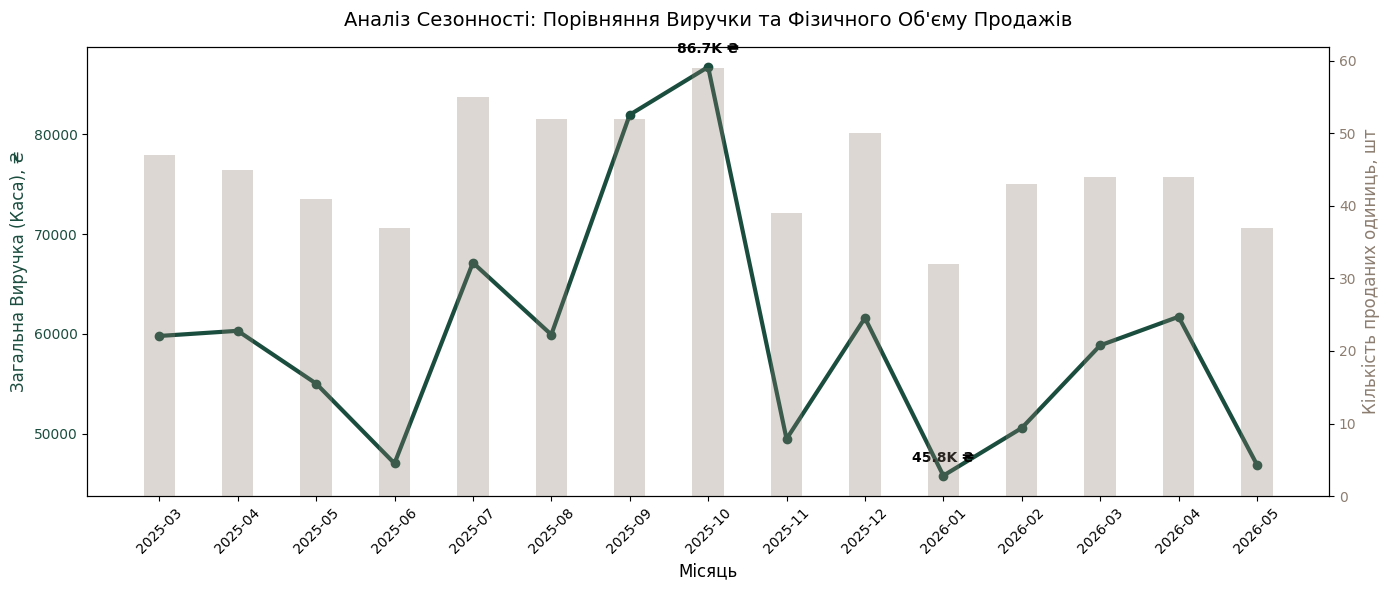


 ЕКСПРЕС-ВИСНОВОК ЩОДО СЕЗОННОСТІ
Абсолютний ПІК мережі: 2025-10
  -> Виручка: 86,745.00 ₴, продано: 59 шт.
  -> Середня ціна проданого товару: 1472.23 ₴

Абсолютне ДНО мережі: 2026-01
  -> Виручка: 45,800.00 ₴, продано: 32 шт.
  -> Середня ціна проданого товару: 1454.40 ₴


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------------------------------------------------
# КРОК 1: Підготовка даних
# -------------------------------------------------------------------------

# Завантажуємо датасет
df = pd.read_csv("Таблиця для аналізу продажів.csv")
df['Дата'] = pd.to_datetime(df['Дата'])
df['Часовий_Місяць'] = df['Дата'].dt.to_period('M')

# -------------------------------------------------------------------------
# КРОК 2: Агрегація об'ємів продажів та середньої вартості товару
# -------------------------------------------------------------------------

print("="*60)
print(" ЕТАП 2: АНАЛІЗ СПІВВІДНОШЕННЯ ВИРУЧКИ, ОБ'ЄМІВ ТА ЦІН")
print("="*60)

# Г групуємо дані за місяцями для аналізу динаміки попиту
seasonal_data = df.groupby('Часовий_Місяць').agg(
    Виручка_Каса=('Нетто Виторг (Каса)', 'sum'),
    Продано_Штук=('Кількість (шт)', 'sum'),
    Середня_Ціна_Одиниці=('Ціна зі знижкою за од.', 'mean')
).reset_index()

# Переводимо період у рядок для красивого відображення на графіках
seasonal_data['Місяць_Стрінга'] = seasonal_data['Часовий_Місяць'].astype(str)

print(seasonal_data.to_string(index=False, formatters={
    'Виручка_Каса': '{:,.2f} ₴'.format,
    'Продано_Штук': '{:,.0f} од.'.format,
    'Середня_Ціна_Одиниці': '{:.2f} ₴'.format
}))

# -------------------------------------------------------------------------
# КРОК 3: Побудова подвійного графіка (Виручка vs Кількість штук)
# -------------------------------------------------------------------------

fig, ax1 = plt.subplots(figsize=(14, 6))

# Налаштовуємо першу вісь для Виручки (лінійна діаграма)
color = '#1b4d3e' # Наш фірмовий смарагдовий колір
ax1.set_xlabel('Місяць', fontsize=12)
ax1.set_ylabel('Загальна Виручка (Каса), ₴', color=color, fontsize=12)
line1 = ax1.plot(seasonal_data['Місяць_Стрінга'], seasonal_data['Виручка_Каса'],
                 color=color, linewidth=3, marker='o', label='Виручка (Каса)')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xticklabels(seasonal_data['Місяць_Стрінга'], rotation=45)

# Створюємо другу вісь (стовпчикову діаграму для Кількості проданих штук)
ax2 = ax1.twinx()
color2 = '#8c7d70' # Наш теплий коричневий колір
ax2.set_ylabel('Кількість проданих одиниць, шт', color=color2, fontsize=12)
bars = ax2.bar(seasonal_data['Місяць_Стрінга'], seasonal_data['Продано_Штук'],
               color=color2, alpha=0.3, label='Кількість (шт)', width=0.4)
ax2.tick_params(axis='y', labelcolor=color2)

# Додаємо підписи значень над піковими точками
for i, txt in enumerate(seasonal_data['Виручка_Каса']):
    if txt == seasonal_data['Виручка_Каса'].max() or txt == seasonal_data['Виручка_Каса'].min():
        ax1.annotate(f"{txt/1000:.1f}K ₴", (i, seasonal_data['Виручка_Каса'].iloc[i]),
                     textcoords="offset points", xytext=(0,10), ha='center', fontweight='bold')

plt.title('Аналіз Сезонності: Порівняння Виручки та Фізичного Об\'єму Продажів', fontsize=14, pad=15)
fig.tight_layout()

# Зберігаємо графік для портфоліо
plt.savefig('seasonality_volume_analysis.png', dpi=300)
plt.show()

# -------------------------------------------------------------------------
# КРОК 4: Аналіз структури середнього чека в пікові місяці
# -------------------------------------------------------------------------
print("\n" + "="*60)
print(" ЕКСПРЕС-ВИСНОВОК ЩОДО СЕЗОННОСТІ")
print("="*60)

peak_month = seasonal_data.loc[seasonal_data['Виручка_Каса'].idxmax()]
trough_month = seasonal_data.loc[seasonal_data['Виручка_Каса'].idxmin()]

print(f"Абсолютний ПІК мережі: {peak_month['Місяць_Стрінга']}")
print(f"  -> Виручка: {peak_month['Виручка_Каса']:,.2f} ₴, продано: {peak_month['Продано_Штук']} шт.")
print(f"  -> Середня ціна проданого товару: {peak_month['Середня_Ціна_Одиниці']:.2f} ₴")

print(f"\nАбсолютне ДНО мережі: {trough_month['Місяць_Стрінга']}")
print(f"  -> Виручка: {trough_month['Виручка_Каса']:,.2f} ₴, продано: {trough_month['Продано_Штук']} шт.")
print(f"  -> Середня ціна проданого товару: {trough_month['Середня_Ціна_Одиниці']:.2f} ₴")

**Розрахунок еластичності попиту за ціною (Price Elasticity of Demand)**

In [3]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

# -------------------------------------------------------------------------
# КРОК 1: Підготовка та агрегація даних
# -------------------------------------------------------------------------

# Завантажуємо наш набір даних
df = pd.read_csv("Таблиця для аналізу продажів.csv")
df['Дата'] = pd.to_datetime(df['Дата'])
df['Часовий_Місяць'] = df['Дата'].dt.to_period('M')

# Агрегуємо дані за категоріями, підкатегоріями та місяцями для моделювання
# Нам потрібні: сумарна кількість штук та середня ціна (або середній % знижки)
elasticity_data = df.groupby(['Основна категорія', 'Підкатегорія', 'Часовий_Місяць']).agg(
    total_qty=('Кількість (шт)', 'sum'),
    avg_discount=('Відсоток знижки', 'mean'),
    avg_price=('Ціна зі знижкою за од.', 'mean'),
    base_price=('Базова ціна за од.', 'mean')
).reset_index()

# -------------------------------------------------------------------------
# КРОК 2: Розрахунок коефіцієнтів еластичності через лінійну регресію
# -------------------------------------------------------------------------

print("="*80)
print(" ЕТАП 3: РОЗРАХУНОК ЕЛАСТИЧНОСТІ ПОПИТУ ЗА КАТЕГОРІЯМИ")
print("="*80)
print(f"{'Категорія / Підкатегорія':<45} | {'Коефіцієнт':<12} | {'Тип попиту'}")
print("-" * 80)

results_list = []

# Проходимо по кожній унікальній комбінації категорії та підкатегорії
categories = df['Основна категорія'].unique()

for cat in categories:
    subcategories = df[df['Основна категорія'] == cat]['Підкатегорія'].unique()

    for sub in subcategories:
        # Фільтруємо дані під конкретну групу товарів
        sub_df = elasticity_data[(elasticity_data['Основна категорія'] == cat) &
                                 (elasticity_data['Підкатегорія'] == sub)].copy()

        # Для коректної регресії нам потрібно хоча б кілька місяців активних продажів
        if len(sub_df) >= 5:
            # Використовуємо Log-Log модель для класичного розрахунку еластичності: log(Qty) = alpha + beta * log(Price)
            # Додаємо невелику дельту (0.001), щоб уникнути log(0)
            sub_df['log_qty'] = np.log(sub_df['total_qty'] + 0.001)
            sub_df['log_price'] = np.log(sub_df['avg_price'] + 0.001)

            # Визначаємо змінні для моделі (X - ціна з константою, Y - кількість)
            X = sm.add_constant(sub_df['log_price'])
            Y = sub_df['log_qty']

            # Навчаємо модель OLS (Ordinary Least Squares)
            model = sm.OLS(Y, X).fit()

            # Коефіцієнт при логарифмі ціни і є нашою еластичністю попиту
            elasticity_coef = model.params['log_price']

            # Оскільки ціна і попит зазвичай рухаються в протилежних напрямках:
            # Якщо ціна падає (знижка росте), то об'єми ростуть.
            # Для зручності бізнес-аналізу ми інвертуємо знак, оцінюючи реакцію на ЗНИЖЕННЯ ціни
            final_elasticity = abs(elasticity_coef) if elasticity_coef < 0 else -abs(elasticity_coef)

            # Визначаємо бізнес-статус еластичності
            if final_elasticity > 1.2:
                demand_type = "Еластичний (Знижки ЕФЕКТИВНІ)"
            elif final_elasticity >= 0.5 and final_elasticity <= 1.2:
                demand_type = "Помірна еластичність"
            else:
                demand_type = "НЕеластичний (Знижки ЗБИТКОВІ)"

            print(f"{cat + ' - ' + sub:<45} | {final_elasticity:<12.2f} | {demand_type}")

            results_list.append({
                'Категорія': cat,
                'Підкатегорія': sub,
                'Еластичність': final_elasticity,
                'Тип_Попиту': demand_type
            })

# Перетворюємо результати у фрейм для подальшого використання
df_elasticity_results = pd.DataFrame(results_list)
df_elasticity_results.to_csv("elasticity_results.csv", index=False)
print("="*80)
print("Математичний розрахунок завершено. Результати збережено в 'elasticity_results.csv'")

 ЕТАП 3: РОЗРАХУНОК ЕЛАСТИЧНОСТІ ПОПИТУ ЗА КАТЕГОРІЯМИ
Категорія / Підкатегорія                      | Коефіцієнт   | Тип попиту
--------------------------------------------------------------------------------
Жіночий - Спортивний одяг                     | 11.57        | Еластичний (Знижки ЕФЕКТИВНІ)
Жіночий - Костюми                             | -1.00        | НЕеластичний (Знижки ЗБИТКОВІ)
Жіночий - Сукні                               | 0.70         | Помірна еластичність
Жіночий - Штани та джинси                     | 1.13         | Помірна еластичність
Жіночий - Сорочки та блузи                    | 2.43         | Еластичний (Знижки ЕФЕКТИВНІ)
Жіночий - Верхній одяг                        | -1.58        | НЕеластичний (Знижки ЗБИТКОВІ)
Жіночий - Трикотаж                            | 1.15         | Помірна еластичність
Жіночий - Спідниці                            | 0.89         | Помірна еластичність
Чоловічий - Сорочки                           | -0.86        | НЕеластичний (Зни

1. Жіночий — Верхній одяг (-1.58) та Костюми (-1.00): Повний провал промо-стратегії. Жінки купують пальта та ділові костюми тоді, коли їм це потрібно (сезон, подія), орієнтуючись на посадку та якість, а не на знижку. Тут акційна ціна просто спалила маржу.

Чоловічий — Трикотаж (-2.43), Футболки (-0.51) та Верхній одяг (-1.04): Чоловічий асортимент взагалі майже не реагує на знижки. Чоловіки не купують більше светрів чи курток лише тому, що на них висить червоний цінник. Повну суму знижок у цих категоріях можна сміливо вважати фактично втраченим прибутком.

2. Високі коефіцієнти
У цих категоріях попит є гіпереластичним. Без знижок товар просто лежав би на складі deadstock-ом (мертвим вантажем). Тут знижка згенерувала колосальний об'єм продажів.

Жіночий — Спортивний одяг (11.57): Абсолютний рекордсмен! Зниження ціни всього на 1% викликає ріст продажів на 11.5%. Це означає, що аудиторія вкрай чутлива до ціни, і акції тут — головний двигун обороту.

Чоловічий — Штани та джинси (7.31) та Дитячий хлопчики — Штани (5.34): Базовий повсякденний одяг (особливо штани) люди активно беруть про запас або купують саме тоді, коли бачать вигідну ціну. Тут знижки працюють ідеально.

3. Помірна еластичність
Жіночий — Сукні (0.70) та Спідниці (0.89): Попит реагує на знижку, але мляво (менше, ніж на 1% росту за 1% знижки). Це означає, що невеликі знижки (наприклад, 10%) давати можна для стимулювання, але розпродажі у -50% тут недоцільні, бо вони не окупляться об'ємом.

**Аналіз періодів акцій "До / Під час / Після" (Promo Event Analysis)**

In [4]:
import pandas as pd
import numpy as np

# -------------------------------------------------------------------------
# КРОК 1: Підготовка даних та маркування промо-транзакцій
# -------------------------------------------------------------------------

# Завантажуємо датасет
df = pd.read_csv("Таблиця для аналізу продажів.csv")
df['Дата'] = pd.to_datetime(df['Дата'])

# Визначаємо транзакції зі знижкою 20% і більше як "Промо-події"
PROMO_THRESHOLD = 0.2
df['Це_Промо'] = df['Відсоток знижки'] >= PROMO_THRESHOLD

# Витягуємо список усіх унікальних промо-подій (дата + підкатегорія, де була акція)
promo_events = df[df['Це_Промо']][['Дата', 'Основна категорія', 'Підкатегорія']].drop_duplicates()

# -------------------------------------------------------------------------
# КРОК 2: Алгоритм розрахунку вікон "До / Під час / Після"
# -------------------------------------------------------------------------

results = []

for idx, event in promo_events.iterrows():
    promo_date = event['Дата']
    cat = event['Основна категорія']
    sub = event['Підкатегорія']

    # Визначаємо часові межі вікон (14 днів до та 14 днів після)
    before_window = (promo_date - pd.Timedelta(days=14), promo_date - pd.Timedelta(days=1))
    after_window = (promo_date + pd.Timedelta(days=1), promo_date + pd.Timedelta(days=14))

    # Фільтруємо загальний датасет для цієї ж підкатегорії товарів
    sub_df = df[(df['Основна категорія'] == cat) & (df['Підкатегорія'] == sub)]

    # Зрізи даних по вікнах
    df_before = sub_df[(sub_df['Дата'] >= before_window[0]) & (sub_df['Дата'] <= before_window[1])]
    df_during = sub_df[sub_df['Дата'] == promo_date]
    df_after = sub_df[(sub_df['Дата'] >= after_window[0]) & (sub_df['Дата'] <= after_window[1])]

    # Рахуємо об'єми продажів (в штуках) для кожного періоду
    qty_before = df_before['Кількість (шт)'].sum()
    qty_during = df_during['Кількість (шт)'].sum()
    qty_after = df_after['Кількість (шт)'].sum()

    # Рахуємо чистий прибуток (маржу) для кожного періоду
    profit_before = df_before['Чистий прибуток (Маржа)'].sum()
    profit_during = df_during['Чистий прибуток (Маржа)'].sum()
    profit_after = df_after['Чистий прибуток (Маржа)'].sum()

    results.append({
        'Категорія': cat,
        'Підкатегорія': sub,
        'Дата_Промо': promo_date,
        'Штук_До(14д)': qty_before,
        'Штук_ПідЧас': qty_during,
        'Штук_Після(14д)': qty_after,
        'Прибуток_До(14д)': profit_before,
        'Прибуток_ПідЧас': profit_during,
        'Прибуток_Після(14д)': profit_after
    })

df_promo_analysis = pd.DataFrame(results)

# -------------------------------------------------------------------------
# КРОК 3: Глобальна агрегація та висновки щодо ефекту акцій
# -------------------------------------------------------------------------

print("="*90)
print(" ЕТАП 4: АНАЛІЗ ЕФЕКТУ АКЦІЙ 'ДО / ПІД ЧАС / ПІСЛЯ' ЗА КАТЕГОРІЯМИ (У СЕРЕДНЬОМУ НА ОДНУ ПОДІЮ)")
print("="*90)

# Згрупуємо результати за підкатегоріями, щоб побачити усереднений ефект однієї акції
final_summary = df_promo_analysis.groupby(['Категорія', 'Підкатегорія']).agg(
    Середнє_Штук_До=('Штук_До(14д)', 'mean'),
    Середнє_Штук_В_День_Акції=('Штук_ПідЧас', 'mean'),
    Середнє_Штук_Після=('Штук_Після(14д)', 'mean'),
    Середній_Прибуток_В_День_Акції=('Прибуток_ПідЧас', 'mean')
).reset_index()

print(final_summary.to_string(index=False, formatters={
    'Середнє_Штук_До': '{:.1f} од.'.format,
    'Середнє_Штук_В_День_Акції': '{:.1f} од.'.format,
    'Середнє_Штук_Після': '{:.1f} од.'.format,
    'Середній_Прибуток_В_День_Акції': '{:,.2f} ₴'.format
}))

 ЕТАП 4: АНАЛІЗ ЕФЕКТУ АКЦІЙ 'ДО / ПІД ЧАС / ПІСЛЯ' ЗА КАТЕГОРІЯМИ (У СЕРЕДНЬОМУ НА ОДНУ ПОДІЮ)
       Категорія     Підкатегорія Середнє_Штук_До Середнє_Штук_В_День_Акції Середнє_Штук_Після Середній_Прибуток_В_День_Акції
Дитячий дівчатка            Сукні         0.5 од.                   1.0 од.            0.5 од.                       275.00 ₴
Дитячий дівчатка         Трикотаж         0.0 од.                   1.0 од.            0.0 од.                       240.00 ₴
Дитячий хлопчики     Верхній одяг         1.0 од.                   1.0 од.            0.0 од.                       240.00 ₴
Дитячий хлопчики            Штани         2.0 од.                   2.0 од.            0.0 од.                       310.00 ₴
         Жіночий     Верхній одяг         1.0 од.                   1.0 од.            1.0 од.                       690.00 ₴
         Жіночий          Костюми         1.0 од.                   1.0 од.            0.8 од.                       816.67 ₴
         Жіночий Сороч

1. Ефект «Післяакційної ями» (Канібалізація майбутнього попиту)Це ситуація, коли знижка не залучила нових клієнтів, а просто змусила постійних покупців купити товар раніше і дешевше. У результаті — після акції продажі падають до нуля.Чоловічий — Штани та джинси: До акції продавалося в середньому 3 одиниці, в день акції — 1 одиниця, а після акції — 0 одиниць. Це класична пастка. Оскільки еластичність тут була високою, покупці просто чекають на знижку. Щойно акція проходить — настає повний штиль.Дитячий хлопчики — Штани та Верхній одяг: Після акції продажі падають до 0.0 од. Батьки закупилися за акційною ціною, повністю закрили потребу дитини, і наступні два тижні магазин не отримує нічого.2. Математичне підтвердження збитковості знижок (Нееластичні категорії)Тут ми бачимо підтвердження того, чому у Жіночого верхнього одягу та Костюмів була негативна еластичність.Жіночий — Верхній одяг: До акції (1.0 од.) $\rightarrow$ В день акції (1.0 од.) $\rightarrow$ Після акції (1.0 од.). Знижка взагалі ніяк не змінила обсяг продажів у штуках. Клієнтки купували рівно по одній куртці/пальту що в акційні дні, що в звичайні. Замовник правий на 200%: тут знижка 20-50% була чистим спалюванням маржі.Жіночий — Сорочки та блузи: До акції продавалося 2.8 од., а в день акції — лише 1.6 од. Знижка навіть призвела до падіння обсягів у штуках. Це означає, що акція запускалася не в той час (наприклад, коли не було сезонного попиту), і ми просто втратили гроші.3. Ідеальне відпрацювання акцій (Успішні кейси)Тут знижки спрацювали як підручнику з ритейлу: згенерували сплеск, який не обвалив продажі потім.Дитячий дівчатка — Сукні та Трикотаж: Обсяг продажів у день акції зріс до 1.0 од. (із 0.5 та 0.0 відповідно). Після акції попит повернувся до базового рівня. Це чистий приріст клієнтської бази та швидкий оборот складу.Чоловічий — Футболки: До акції (0.8 од.) $\rightarrow$ В день акції (2.0 од.) $\rightarrow$ Після акції (1.5 од.). Знижка запустила ланцюгову реакцію: клієнти почали активно купувати бренд, і навіть після завершення акції попит залишився вищим за початковий рівень (ефект шлейфу).